In [17]:
import librosa
import numpy as np

# Load audio
y, sr = librosa.load('datasets/bcmi/bcmi-calibration/stimuli/hvha1.wav')
yy = y 
y = y[:sr*3]

# Detect onsets using spectral flux (default method)
onset_times = librosa.onset.onset_detect(y=y, sr=sr, 
                                          units='time', 
                                          hop_length=512,
                                          )

# Or use the superflux method for better vibrato handling
odf = librosa.onset.onset_strength(y=y, sr=sr, 
                                  aggregate=np.mean,
                                  fmax=8000, 
                                  n_mels=128,
                                  hop_length=256
                                  )
onsets = librosa.onset.onset_detect(onset_envelope=odf, 
                                   sr=sr, 
                                   units='time')
onset_times

array([0.13931973, 0.30185941, 0.58049887, 1.11455782, 1.34675737,
       1.85759637, 2.39165533, 2.69351474])

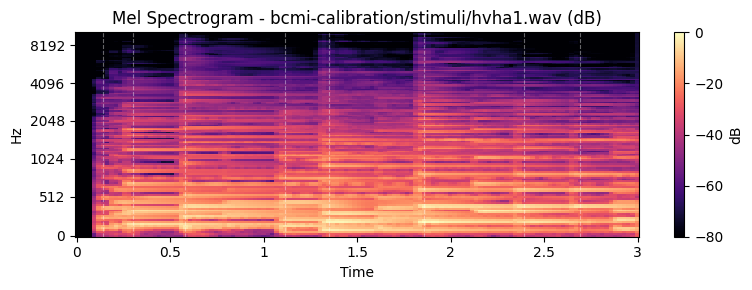

In [18]:
from eeg_music.data import mkplot_melspectrogram, WavRAW

fig = mkplot_melspectrogram(
        WavRAW(raw_data=y, sample_rate=int(sr)),
        title=f"Mel Spectrogram - {"bcmi-calibration/stimuli/hvha1.wav"}",
        fmax=10240.0,
        onset_times=onset_times
        # onset_times=onsets
      )

WavRAW(raw_data=array([ 1.4374498e-05, -1.6292513e-05,  3.6012602e-06, ...,
       -2.6231715e-02, -2.4914168e-02, -2.1545118e-02],
      shape=(66150,), dtype=float32), sample_rate=22050) 2.8908844


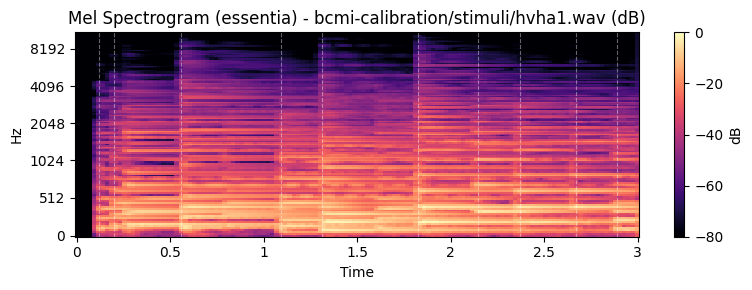

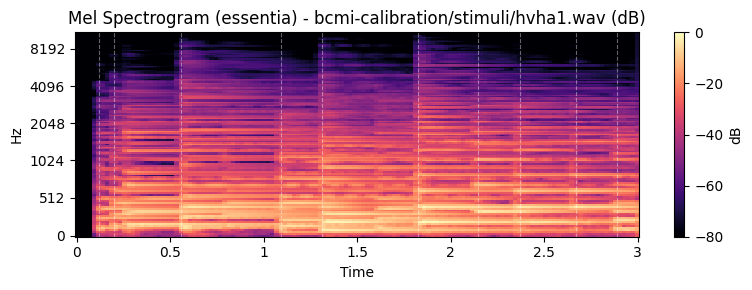

In [19]:
from eeg_music.onset_markers import detect_onsets_wavraw
import matplotlib.pyplot as plt

def try_essentia(y, hop_size=256, frame_size=1024, method="hfc"):
    if len(y.raw_data.shape) > 1:
      y.raw_data = y.raw_data[:, 0]
    onset_times_ess = detect_onsets_wavraw(y, hop_size=hop_size, frame_size=frame_size, method=method)
    fig = mkplot_melspectrogram(
            y,
        title=f"Mel Spectrogram (essentia) - {"bcmi-calibration/stimuli/hvha1.wav"}",
        # fmax=10240.0,
        onset_times=onset_times_ess
        # onset_times=onsets
      )
    print( y ,  onset_times_ess[-1])

    return fig

try_essentia(WavRAW(raw_data=y, sample_rate=int(sr)))

In [4]:
! ls datasets/bcmi/bcmi-calibration/stimuli

hvha10.wav  hvla5.wav	lvha12.wav  lvla7.wav	nvha1.wav   nvla8.wav
hvha11.wav  hvla6.wav	lvha1.wav   lvla8.wav	nvha2.wav   nvla9.wav
hvha12.wav  hvla7.wav	lvha2.wav   lvla9.wav	nvha3.wav   nvna10.wav
hvha1.wav   hvla8.wav	lvha3.wav   lvna10.wav	nvha4.wav   nvna11.wav
hvha2.wav   hvla9.wav	lvha4.wav   lvna11.wav	nvha5.wav   nvna12.wav
hvha3.wav   hvna10.wav	lvha5.wav   lvna12.wav	nvha6.wav   nvna1.wav
hvha4.wav   hvna11.wav	lvha6.wav   lvna1.wav	nvha7.wav   nvna2.wav
hvha5.wav   hvna12.wav	lvha7.wav   lvna2.wav	nvha8.wav   nvna3.wav
hvha6.wav   hvna1.wav	lvha8.wav   lvna3.wav	nvha9.wav   nvna4.wav
hvha7.wav   hvna2.wav	lvha9.wav   lvna4.wav	nvla10.wav  nvna5.wav
hvha8.wav   hvna3.wav	lvla10.wav  lvna5.wav	nvla11.wav  nvna6.wav
hvha9.wav   hvna4.wav	lvla11.wav  lvna6.wav	nvla12.wav  nvna7.wav
hvla10.wav  hvna5.wav	lvla12.wav  lvna7.wav	nvla1.wav   nvna8.wav
hvla11.wav  hvna6.wav	lvla1.wav   lvna8.wav	nvla2.wav   nvna9.wav
hvla12.wav  hvna7.wav	lvla2.wav   lvna9.wav	nvla3.wav   wav_lengths

[ WARNING  ] Onsets: 172.266 is not supported as frame rate.
This implementation depends on a frameRate of 44100.0/512.0.
Still going on, but results might not be as good as expected...
/tmp/ipykernel_41260/4205348202.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


WavRAW(raw_data=array([-3.0517578e-05, -9.1552734e-05, -1.2207031e-04, ...,
       -3.2000732e-01, -3.4982300e-01, -3.7478638e-01],
      shape=(176400,), dtype=float32), sample_rate=44100) 3.9996371


[ WARNING  ] Onsets: 46.875 is not supported as frame rate.
This implementation depends on a frameRate of 44100.0/512.0.
Still going on, but results might not be as good as expected...


WavRAW(raw_data=array([-2.9421883e-05, -1.2622281e-05,  6.4761749e-05, ...,
       -1.6729375e-02,  5.5730697e-02,  1.0822226e-01],
      shape=(48000,), dtype=float32), sample_rate=12000) 3.8613334


[ WARNING  ] Onsets: 344.531 is not supported as frame rate.
This implementation depends on a frameRate of 44100.0/512.0.
Still going on, but results might not be as good as expected...


WavRAW(raw_data=array([ 1.6405664e-05, -7.5001972e-06, -1.6361932e-05, ...,
        8.4141113e-02,  8.3045237e-02,  8.1970192e-02],
      shape=(352800,), dtype=float32), sample_rate=88200) 3.9619048
WavRAW(raw_data=array([ 0.        ,  0.        ,  0.        , ..., -0.32078198,
       -0.30151325, -0.31007525], shape=(88200,), dtype=float32), sample_rate=22050) 3.9822223
WavRAW(raw_data=array([ 0.        ,  0.        ,  0.        , ..., -0.24936824,
       -0.23896904, -0.23221697], shape=(88200,), dtype=float32), sample_rate=22050) 4.005442


[ WARNING  ] Onsets: 62.5 is not supported as frame rate.
This implementation depends on a frameRate of 44100.0/512.0.
Still going on, but results might not be as good as expected...
[ WARNING  ] Onsets: 172.266 is not supported as frame rate.
This implementation depends on a frameRate of 44100.0/512.0.
Still going on, but results might not be as good as expected...


WavRAW(raw_data=array([-1.5121800e-07,  1.7530175e-07, -1.8473582e-07, ...,
       -2.3662828e-01, -2.1305780e-01, -1.9528030e-01],
      shape=(64000,), dtype=float32), sample_rate=16000) 4.0
WavRAW(raw_data=array([ 0.        ,  0.        ,  0.        , ..., -0.09732056,
       -0.09564209, -0.09277344], shape=(176400,), dtype=float32), sample_rate=44100) 3.7384126


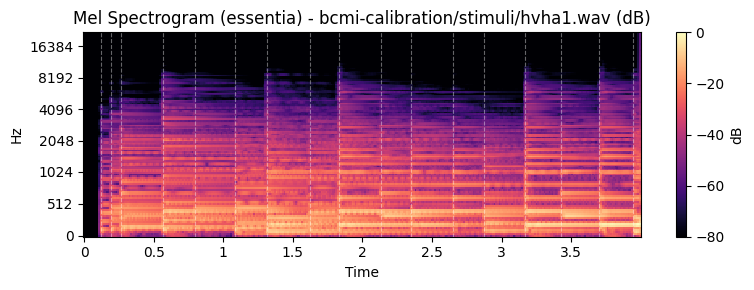

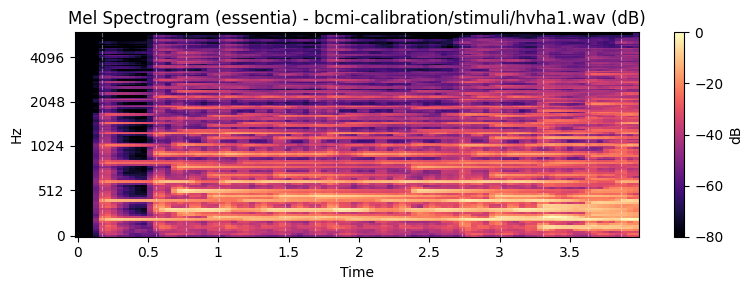

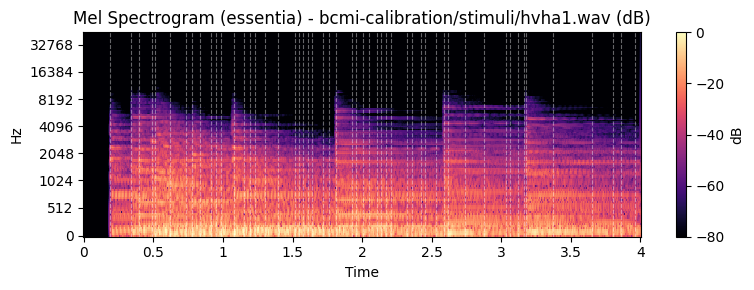

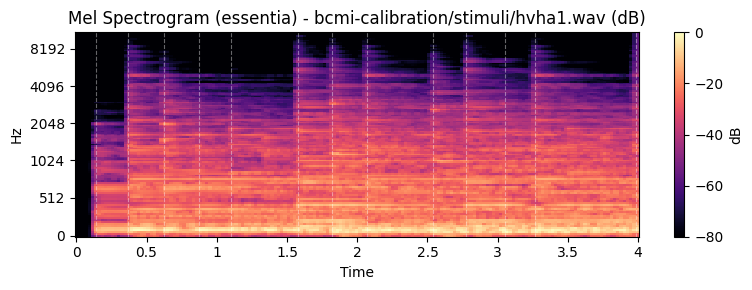

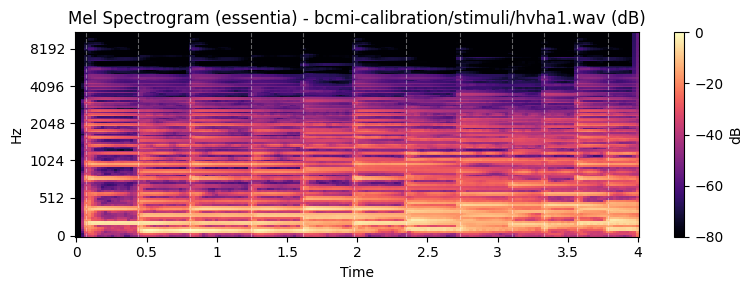

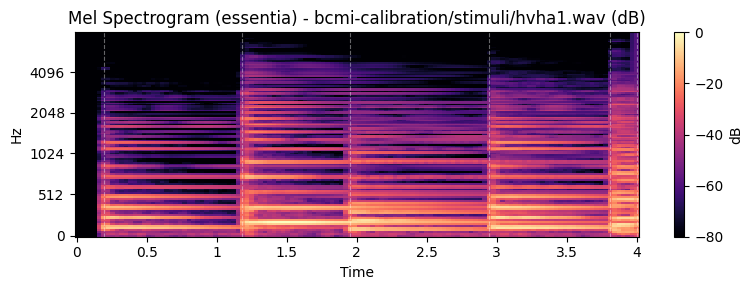

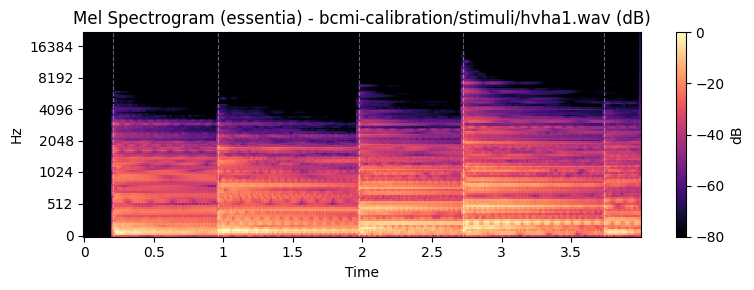

In [38]:
from eeg_music.data import OnDiskMusic, WavRAW
from pathlib import Path

def random_resample(wav: WavRAW):
  freqs = [44100, 22050, 16000, 12000, 88200]
  freq = np.random.choice(freqs)
  return wav.resampled(int(freq))


wav1 = OnDiskMusic(filepath=Path("datasets/bcmi/bcmi-calibration/stimuli/hvha1.wav"))
wav2 = OnDiskMusic(filepath=Path("datasets/bcmi/bcmi-calibration/stimuli/hvha2.wav"))
wav3 = OnDiskMusic(filepath=Path("datasets/bcmi/bcmi-calibration/stimuli/lvha7.wav"))
wav4 = OnDiskMusic(filepath=Path("datasets/bcmi/bcmi-calibration/stimuli/lvna2.wav"))
wav5 = OnDiskMusic(filepath=Path("datasets/bcmi/bcmi-calibration/stimuli/nvna9.wav"))
wav6 = OnDiskMusic(filepath=Path("datasets/bcmi/bcmi-calibration/stimuli/nvla6.wav"))
wav7 = OnDiskMusic(filepath=Path("datasets/bcmi/bcmi-calibration/stimuli/lvla6.wav"))

for wav in [wav1, wav2, wav3, wav4, wav5, wav6, wav7]:
  y: WavRAW = wav.get_music()
  if len(y.raw_data.shape) > 1:
    y.raw_data = y.raw_data[:, 0]
  y = random_resample(y)
  y.raw_data = y.raw_data[:y.sample_rate * 4]
  fig = try_essentia(y, method='complex')
  # fig = try_essentia(y, method='melflux')
  fig.show()

# mus1: WavRAW = wav1.get_music()
# mus1.raw_data = mus1.raw_data[:, 0]
# fig = try_essentia(mus1)
# fig.show()


((66150,), (873315, 2))